In [163]:
import sys
sys.path.append('../functions')
from importlib import reload
import sepsis_func
reload(sepsis_func)
from sepsis_func import *
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.utils import resample
import multiprocessing
import matplotlib.pyplot as plt


## Load and process data

In [ ]:
rng = np.random.default_rng(2023)
train_nosepsis = np.load('../data/train_nosepsis.npy')
train_sepsis = np.load('../data/train_sepsis.npy')
test_nosepsis = np.load('../data/test_nosepsis.npy')
test_sepsis = np.load('../data/test_sepsis.npy')
# sub set the no sepsis subjects
train_nosepsis_index =  rng.choice(len(train_nosepsis), size = len(train_sepsis), replace = False)
test_nosepsis_index = rng.choice(len(test_nosepsis), size = len(test_sepsis)*2, replace = False)
# get the final train and test datset
train_nosepsis_sub = train_nosepsis[train_nosepsis_index]
test_nosepsis_sub =  test_nosepsis[test_nosepsis_index]

train_set = np.concatenate((train_nosepsis_sub,train_sepsis))
test_set = np.concatenate((test_nosepsis_sub,test_sepsis))


In [ ]:
train_features, train_labels, train_ids = data_process(train_set, "../data/all_dataset_sepsis/")


In [ ]:
test_features, test_labels, test_ids = data_process(test_set, "../data/all_dataset_sepsis/")


## Load the best parameters for XGboost

In [ ]:
import json 
def flatten(input_dict, d = {}):    
    for key, val in input_dict.items():
        if isinstance(val, dict):
            flatten(val)
        else:
            d[key] = val
    return d
best_model = xgb.Booster(model_file = "../data/xgb_model/model1.mdl")
best_param = json.loads(best_model.save_config())
best_param = flatten(best_param)

In [ ]:
print(best_param['max_depth'])
print(best_param['learning_rate'])
print(best_param['subsample'])
print(best_param['colsample_bytree'])
print(best_param['reg_alpha'])
print(best_param['reg_lambda'])

6
0.300000012
1
1
0
1


## Bootstrap

In [ ]:
def bootstrap_time_series(X,y,ids):
    # Get unique IDs
    unique_ids = np.unique(ids)
    
    # Bootstrap IDs
    bootstrapped_ids = resample(unique_ids, replace=True)
    
    # Initialize empty list to store bootstrapped feature data
    bootstrapped_X = []
    bootstrapped_y = []
    # For each ID in bootstrapped IDs
    for id_ in bootstrapped_ids:
        # Get the index of the features associated with the ID
        id_index = np.where(ids == id_)[0]
        
        # Get the features associated with the ID
        id_features = X[id_index]
        id_y = y[id_index]
        # Append the bootstrapped features to the list
        bootstrapped_X.append(id_features)
        bootstrapped_y.append(id_y)
    # Concatenate all bootstrapped feature data
    bootstrapped_X = np.concatenate(bootstrapped_X, axis=0)
    bootstrapped_y = np.concatenate(bootstrapped_y, axis=0)
    return bootstrapped_X, bootstrapped_y

def train_boot(train_features, train_labels, train_ids, test_features, best_param):
    X_boot, y_boot = bootstrap_time_series(train_features, train_labels, train_ids)
    X_train, X_val, y_train, y_val = train_test_split(X_boot, y_boot, test_size = 0.15, random_state = 1)
    model = train_model(X_train, y_train, X_val, y_val,best_param)
    pred_prob = (model.predict_proba(test_features, ntree_limit=xgb_model.best_ntree_limit))[:, 1]
    return pred_prob

def train_boot_wrapper(kwargs):
    train_boot(**kwargs)

In [ ]:
n_boot = 10
param = {'train_features':train_features, 'train_labels': train_labels, 'train_ids' :train_ids, 'test_features':test_features, 'best_param':best_param}
if __name__ ==  '__main__': 
    ctx = multiprocessing.get_context('spawn')
    pool_obj = ctx.Pool()
    cur_para = (n_boot*(param,))
    pool_obj.map(train_boot_wrapper, cur_para)
    pool_obj.close()
    pool_obj.join()

KeyboardInterrupt: 

In [ ]:
n_boot = 1
prob_matrix_boot = []
for i in range(n_boot):
    X_boot, y_boot = bootstrap_time_series(train_features, train_labels, train_ids)
    X_train, X_val, y_train, y_val = train_test_split(X_boot, y_boot, test_size = 0.15, random_state = 1)
    model = train_model(X_train, y_train, X_val, y_val,best_param)
    pred_prob = (model.predict_proba(test_features, ntree_limit=model.best_ntree_limit))[:, 1]
    prob_matrix_boot.append(pred_prob)
prob_matrix_boot = np.array(prob_matrix_boot)
# Point prediction
point_pred = np.mean(prob_matrix_boot, axis = 0)
se = np.std(prob_matrix_boot, axis = 0)
#return point_pred, prob_matrix_boot, se


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  UserWarning,
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  UserWarning,
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/core.py:94: UserWarning: ntree_limit is deprecated, use `iteration_range` or model slicing instead.
  UserWarning


training dataset AUC: 0.9999951479601518
training dataset acc: 0.9995020936960083
validation dataset AUC: 0.9986123465352346


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/core.py:94: UserWarning: ntree_limit is deprecated, use `iteration_range` or model slicing instead.
  UserWarning


validation dataset acc: 0.9917332054284344
************************************************************


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/core.py:94: UserWarning: ntree_limit is deprecated, use `iteration_range` or model slicing instead.
  UserWarning
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  UserWarning,
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  UserWarning,


...

training dataset AUC: 0.9999881999717548
training dataset acc: 0.999377649850247
validation dataset AUC: 0.9984436056948316


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/core.py:94: UserWarning: ntree_limit is deprecated, use `iteration_range` or model slicing instead.
  UserWarning


validation dataset acc: 0.9919550363676438
************************************************************


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/core.py:94: UserWarning: ntree_limit is deprecated, use `iteration_range` or model slicing instead.
  UserWarning
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  UserWarning,
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  UserWarning,


KeyboardInterrupt: 

In [ ]:
prob_matrix_boot = np.log(prob_matrix_boot/(1-prob_matrix_boot))
#prob_matrix_boot = np.array(prob_matrix_boot)
# Point prediction
point_pred = np.mean(prob_matrix_boot, axis = 0)
se = np.std(prob_matrix_boot, axis = 0)
#return point_pred, prob_matrix_boot, se

In [ ]:
point_pred = model.predict(test_features, output_margin = True)

In [ ]:
pred_label = [0 if i <= 0 else 1 for i in point_pred]


In [ ]:
accuracy_score(test_labels, pred_label)

0.9100316133155977

In [ ]:
prob_matrix_boot.shape



(146, 57887)

In [198]:
se[875]

2.207571

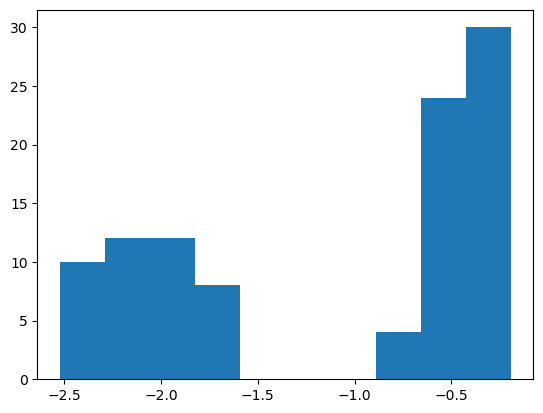

In [420]:
plt.hist(prob_matrix_boot[:, 21])
plt.show()

## Load bootstrap result from Desktop

In [625]:
prob_matrix_boot = np.load('../data/sepsis_pred_raw_m.npy')
test_labels = np.load('../data/test_labels.npy')
train_sub_ids = np.load('../data/train_ids.npy')
train_labels = np.load('../data/train_labels.npy')

In [621]:
train_sub_ids.shape

(32723,)

In [623]:
np.unique(train_sub_ids).shape

(600,)

In [627]:
np.sum(train_labels)

3795

In [ ]:
prob_matrix_boot.shape

(100, 9832)

In [628]:
test_labels.shape

(9832,)

In [629]:
np.mean(test_labels)

0.09764035801464606

In [630]:
np.sum(test_labels)

960

In [609]:
prob_matrix_boot

array([[ 3.8088784 , -4.0054965 , -6.520784  , ..., -7.2137504 ,
        -3.4770103 , -7.1141696 ],
       [ 2.074826  , -5.025737  , -6.7155366 , ..., -8.720762  ,
        -1.2404734 , -7.1093674 ],
       [ 0.37305367, -4.6601644 , -5.9586787 , ..., -8.503076  ,
        -1.0489001 , -5.7417297 ],
       ...,
       [-0.84492964, -4.979094  , -6.094345  , ..., -7.5987325 ,
        -2.4566061 , -7.2713013 ],
       [ 0.74727595, -3.121038  , -5.5955725 , ..., -8.571782  ,
        -4.267841  , -6.7160435 ],
       [ 2.2442558 , -2.7794423 , -6.931966  , ..., -6.8641787 ,
        -2.3902025 , -5.8995147 ]], dtype=float32)

In [610]:
point_pred = np.mean(prob_matrix_boot, axis = 0)
se = np.std(prob_matrix_boot, axis = 0)

In [611]:
import sys
sys.path.append('../functions')
import confidence_set_func
#import importlib
#importlib.reload(confidence_set_func)
level = 0
G, mean, se =confidence_set_func.process_boot_samples(prob_matrix_boot, point_pred, se, None, 
                                      False, second_stage=False, center_G = True, center_pred = False)
dict_, L, U, _, _, _ = confidence_set_func.prediction_confidence_set(0.95, level, mean, se, G, mean_test_true = None, use_true_contour = False)

In [612]:
print(L)
print(U)

0.9499999999989086
0.99


In [613]:
dict_['inner_non_sepsis'] = ~dict_['outer']
dict_['outer_non_sepsis'] = ~dict_['inner']

In [614]:
test_auc = roc_auc_score(test_labels, point_pred)
print('testing dataset AUC: ' + str(test_auc))
y_test_class = np.array([0 if i <= 0 else 1 for i in point_pred])
acc = accuracy_score(test_labels, y_test_class)
print('testing dataset acc: ' + str(acc))

testing dataset AUC: 0.6728391169785093
testing dataset acc: 0.8784580960130187


### Classification for sepsis observations

In [615]:
print('Point prediction')
num_positive = np.sum(y_test_class==1)
print(f'number positive: {num_positive}')
sensitivity = np.mean(np.array(y_test_class)[test_labels==1])
precision = np.mean(test_labels[np.array(y_test_class)==1])
print(f'sensitivity is {sensitivity}')
print(f'precision is {precision}')

Point prediction
number positive: 411
sensitivity is 0.09166666666666666
precision is 0.2141119221411192


In [618]:
print('Inner set')
num_positive = np.sum(dict_['inner'])
print(f'number positive: {num_positive}')
sensitivity = np.mean(np.array(dict_['inner'])[test_labels==1])
precision = np.mean(test_labels[np.array(dict_['inner'])])
print(f'sensitivity is {sensitivity}')
print(f'precision is {precision}')

Inner set
number positive: 7
sensitivity is 0.004166666666666667
precision is 0.5714285714285714


In [619]:
print('Outer set')
num_positive = np.sum(dict_['outer'])
print(f'number positive: {num_positive}')
sensitivity = np.mean(np.array(dict_['outer'])[test_labels==1])
precision = np.mean(test_labels[np.array(dict_['outer'])])
print(f'sensitivity is {sensitivity}')
print(f'precision is {precision}')

Outer set
number positive: 3051
sensitivity is 0.5270833333333333
precision is 0.16584726319239593


### Classifications for non-sepsis patients


In [596]:
print('Point prediction')
num_positive = np.sum(y_test_class==0)
print(f'number positive: {num_positive}')
sensitivity = np.mean(1-np.array(y_test_class)[test_labels==0])
precision = np.mean(1-test_labels[np.array(y_test_class)==0])
print(f'sensitivity is {sensitivity}')
print(f'precision is {precision}')

Point prediction
number positive: 7261
sensitivity is 0.9605519724013799
precision is 0.8819721801404765


In [598]:
print('Inner set')
num_positive = np.sum(dict_['inner_non_sepsis'])
print(f'number positive: {num_positive}')
sensitivity = np.mean(np.array(dict_['inner_non_sepsis'])[test_labels==0])
precision = np.mean(1-test_labels[np.array(dict_['inner_non_sepsis'])])
print(f'sensitivity is {sensitivity}')
print(f'precision is {precision}')

Inner set
number positive: 5057
sensitivity is 0.6907154642267886
precision is 0.9106189440379672


In [599]:
print('Outer set')
num_positive = np.sum(dict_['outer_non_sepsis'])
print(f'number positive: {num_positive}')
sensitivity = np.mean(np.array(dict_['outer_non_sepsis'])[test_labels==0])
precision = np.mean(1-test_labels[np.array(dict_['outer_non_sepsis'])])
print(f'sensitivity is {sensitivity}')
print(f'precision is {precision}')

Outer set
number positive: 7529
sensitivity is 0.9916004199790011
precision is 0.8780714570328065


# Interpretation using CS

In [ ]:
from scipy import stats
def CS_t_test(inner_index, outer_index, X_test):
    n_inner = np.sum(inner_index)
    n_comp_outer = np.sum(~outer_index)
    p_values = []
    for j in range(X_test.shape[1]):
        x_j = X_test.iloc[:,j]
        if x_j.dtype not in ['float64','int64']:
            #import pdb; pdb.set_trace()
            temp1 = pd.concat([pd.Series(['inner']).repeat(len(x_j[inner_index])), pd.Series(['outer']).repeat(len(x_j[~outer_index]))] ).reset_index(drop = True)
            temp2 = pd.concat((x_j[inner_index],x_j[~outer_index])).reset_index(drop = True)
            temp = pd.concat( (temp2, temp1),axis = 1)
            tab = pd.crosstab(temp.iloc[:,1],temp.iloc[:,0])
            res = stats.chi2_contingency(tab)
            p_values.append(res[1])
        else:
            if len(np.unique(x_j))>2:
                p_values.append(stats.mannwhitneyu(x_j[inner_index], x_j[~outer_index])[1])
            else:# binomial two sample t-test
                p_values.append(stats.ttest_ind(x_j[inner_index], x_j[~outer_index])[1])
    return np.array(p_values)
    #import pdb; pdb.set_trace()
    # mean1 = np.mean(X_test[inner_index], axis = 0) 
    # mean2 = np.mean(X_test[~outer_index], axis = 0)
    # sd1 = np.std(X_test[inner_index], axis = 0)
    # sd2 = np.std(X_test[~outer_index], axis = 0)
    # var_mean1 = sd1**2/n_inner
    # var_mean2 = sd2**2/n_comp_outer
    # t = (mean1 - mean2 )/np.sqrt(var_mean1+var_mean2)
    # v = (var_mean1+var_mean2)**2/(var_mean1/(n_inner-1)+var_mean2/(n_comp_outer-1))
    # t_q = stats.t.ppf(0.975, v)
    #return stats.mannwhitneyu(X_test[inner_index], X_test[~outer_index])
p = CS_t_test(dict_['inner'], dict_['outer'], pd.DataFrame(X_test))
index_top = np.where( np.isin(p,np.sort(p)[0:3]))[0]
significant_col = df.columns[index_top]
#significant_col = np.unique([x.split('_')[0] for x in significant_col])
CS_importances = pd.Series(-np.log(p[index_top]), index=significant_col)



In [ ]:
CS_importances

In [ ]:
list(df.columns)